# 4 data points lied to us: a lesson in backtest sample size

**Companion notebook to [`src/backtesting.py`](../src/backtesting.py)** — this narrates the project's most consequential methodological finding, using the same `data/processed/` outputs the README documents.

## The setup

This project simulates a hypothetical superteam's season and asks: how does the simulated win distribution compare to reality for teams that actually existed? The first version of this check used 4 famous "superteam" comparables: the 2010-11 Heat, 2016-17 Warriors, 2020-21 Nets, and 2022-23 Suns — teams built by stacking stars, exactly the scenario this whole project simulates.

## First reading (uncalibrated model)

With the original parameters, 3 of those 4 teams came back wildly overestimated by the model — the two with documented real-world chemistry problems (Nets, Suns) fell in the <1st percentile of the simulated distribution. The tempting story: **the model captures raw talent but misses the human friction of stacking egos** — and for a while, that was this README's headline finding.

## Second reading: what actually happened

Scaling backtesting from 4 cases to 480 (30 teams x 16 seasons, every team, not just superteams) surfaced **three real calibration bugs** that caused the model to overestimate *every* team, not just star-stacked ones: a fixed win-rate baseline that didn't track a league that scores more every year, un-normalized roster minutes, and an invented Game Score -> point-differential scale. Once those were fixed, the same 4 cases flipped: the two teams that genuinely *overperformed* (Heat 58 wins, Warriors 67 wins) came back *underestimated*, and the two with real documented friction (Nets, Suns) landed in reasonable percentiles.

**The honest conclusion:** a good chunk of the original "finding" was a calibration artifact, not evidence of superteam friction. With 4 data points it was impossible to tell "the model has a mechanical bias" apart from "there's a real friction effect" — it took 480 cases to separate them, and the answer was mostly the former.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "data" / "processed"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

sweep = pd.read_csv(DATA / "backtest_sweep_summary.csv")
calibration = pd.read_csv(DATA / "backtest_sweep_calibration.csv")
comparables = pd.read_csv(DATA / "backtest_summary.csv")  # the 4 narrative superteam cases, current (calibrated) numbers

print(f"{len(sweep)} backtest-sweep cases, {sweep['season'].nunique()} seasons")
calibration.T


480 backtest-sweep cases, 16 seasons


,0
n_cases,480.000000
pct_within_p10_p90,61.250000
mean_percentile,52.071688
median_percentile,54.605000
mean_absolute_error_wins,6.777201
mean_error_wins,-0.036330
correlation_actual_vs_predicted,0.749153


## Calibration plot: 480 cases, actual wins vs. simulated wins

Every point is one team-season. A perfectly calibrated model would put every point on the diagonal. The 4 narrative superteam cases are highlighted.


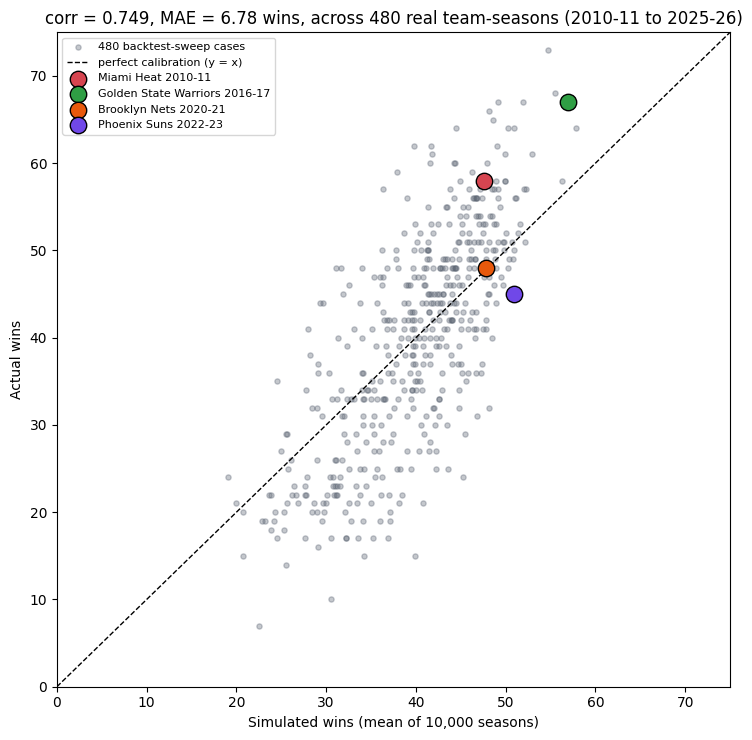

In [2]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.scatter(sweep["simulated_wins_mean"], sweep["actual_wins"], s=14, alpha=0.35, color="#5b6472", label="480 backtest-sweep cases")

lims = [0, 75]
ax.plot(lims, lims, color="black", linewidth=1, linestyle="--", label="perfect calibration (y = x)")

colors = {"Miami Heat 2010-11": "#d64550", "Golden State Warriors 2016-17": "#2f9e44", "Brooklyn Nets 2020-21": "#e8590c", "Phoenix Suns 2022-23": "#7048e8"}
for _, row in comparables.iterrows():
    c = colors.get(row["comparable_name"], "#000000")
    ax.scatter(row["simulated_wins_mean"], row["actual_wins"], s=140, color=c, edgecolor="black", zorder=5, label=row["comparable_name"])

ax.set_xlabel("Simulated wins (mean of 10,000 seasons)")
ax.set_ylabel("Actual wins")
ax.set_xlim(*lims)
ax.set_ylim(*lims)
corr = calibration["correlation_actual_vs_predicted"].iloc[0]
mae = calibration["mean_absolute_error_wins"].iloc[0]
ax.set_title(f"corr = {corr:.3f}, MAE = {mae:.2f} wins, across 480 real team-seasons (2010-11 to 2025-26)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## The 4 narrative cases, before vs. after calibration

The numbers below (before) are transcribed from the project's own history (documented in the README) -- the uncalibrated model was superseded once the sweep found the underlying bugs, so its outputs aren't in `data/processed/` anymore. The "after" numbers are read live from `backtest_summary.csv`.


In [3]:
before = pd.DataFrame([
    {"comparable_name": "Miami Heat 2010-11", "actual_wins": 58, "simulated_wins_median_before": 68, "percentile_before": 7.7},
    {"comparable_name": "Golden State Warriors 2016-17", "actual_wins": 67, "simulated_wins_median_before": 70, "percentile_before": 33.9},
    {"comparable_name": "Brooklyn Nets 2020-21", "actual_wins": 48, "simulated_wins_median_before": 67, "percentile_before": 0.25},
    {"comparable_name": "Phoenix Suns 2022-23", "actual_wins": 45, "simulated_wins_median_before": 74, "percentile_before": 0.05},
])

after = comparables[["comparable_name", "actual_wins", "simulated_wins_p50", "actual_percentile"]].rename(
    columns={"simulated_wins_p50": "simulated_wins_median_after", "actual_percentile": "percentile_after"}
)

combined = before.merge(after.drop(columns="actual_wins"), on="comparable_name")
combined


,comparable_name,actual_wins,simulated_wins_median_before,percentile_before,simulated_wins_median_after,percentile_after
0,Miami Heat 2010-11,58,68,7.70,48.0,97.94
1,Golden State Warriors 2016-17,67,70,33.90,57.0,98.89
2,Brooklyn Nets 2020-21,48,67,0.25,48.0,52.74
3,Phoenix Suns 2022-23,45,74,0.05,51.0,18.79


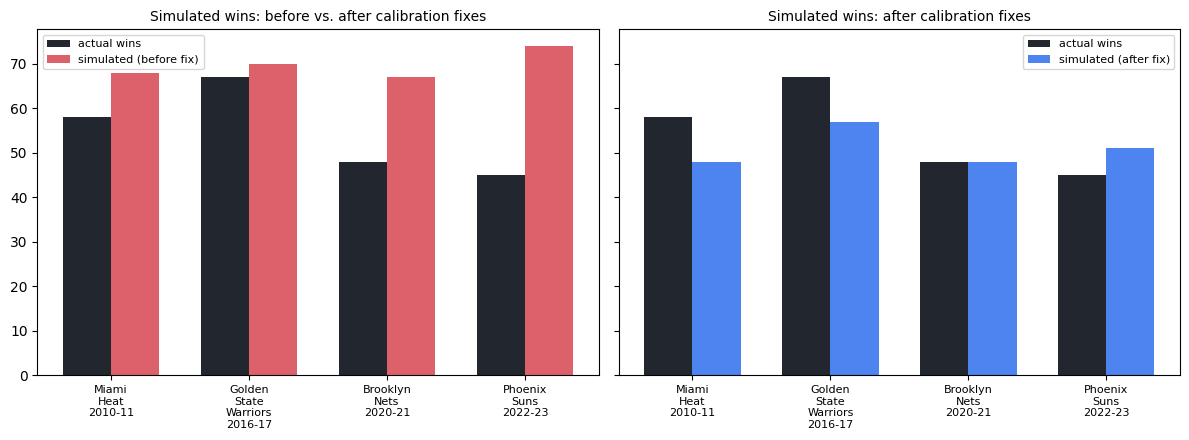

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
x = np.arange(len(combined))
width = 0.35

for ax, before_col, after_col, title in [
    (axes[0], "simulated_wins_median_before", "simulated_wins_median_after", "Simulated wins: before vs. after calibration fixes"),
]:
    ax.bar(x - width / 2, combined["actual_wins"], width, label="actual wins", color="#22262e")
    ax.bar(x + width / 2, combined[before_col], width, label="simulated (before fix)", color="#d64550", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(" ", "\n") for n in combined["comparable_name"]], fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

ax = axes[1]
ax.bar(x - width / 2, combined["actual_wins"], width, label="actual wins", color="#22262e")
ax.bar(x + width / 2, combined["simulated_wins_median_after"], width, label="simulated (after fix)", color="#2f6fed", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([n.replace(" ", "\n") for n in combined["comparable_name"]], fontsize=8)
ax.set_title("Simulated wins: after calibration fixes", fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


Before the fix, the model overestimated all 4 teams -- badly for Nets/Suns. After, it *underestimates* the two teams that genuinely overperformed (Heat, Warriors) and gets much closer on Nets/Suns. The pattern didn't just shrink, it **flipped** -- which is exactly what you'd expect if the original story was mostly a systematic bias, not a superteam-specific effect.

## Percentile distribution across all 480 cases

If the model were well-calibrated, `actual_percentile` (where the real outcome falls in the simulated distribution) should be roughly uniform between 0 and 100 -- no team should be systematically pushed to one end.


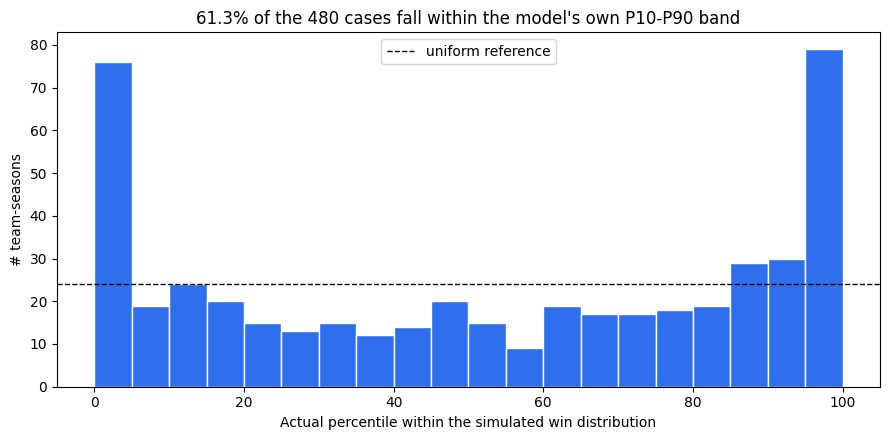

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(sweep["actual_percentile"], bins=20, color="#2f6fed", edgecolor="white")
ax.axhline(len(sweep) / 20, color="black", linestyle="--", linewidth=1, label="uniform reference")
ax.set_xlabel("Actual percentile within the simulated win distribution")
ax.set_ylabel("# team-seasons")
pct_within = calibration["pct_within_p10_p90"].iloc[0]
ax.set_title(f"{pct_within:.1f}% of the 480 cases fall within the model's own P10-P90 band")
ax.legend()
plt.tight_layout()
plt.show()


That's not actually uniform -- it's U-shaped, with cases piling up near both extremes (0-5% and 95-100%) more than a well-calibrated model should produce. Read honestly: `mean_error_wins` being close to zero (the earlier calibration table) hides that the model is *overconfident* -- its P10-P90 band is too narrow, so real outcomes fall outside it more often than the 20% you'd expect from a well-calibrated interval. That's a legitimate open question for this project, not something this notebook set out to fix -- flagged here rather than smoothed over, in the same spirit as the two negative results in the other notebooks.

## Conclusion

> With 4 data points it was impossible to distinguish "the model has a mechanical bias" from "there's a real > superteam friction effect". It took 480 cases to separate them, and the answer was mostly the former. A > small sample can produce a convincing and wrong narrative.

A residual overestimation bias remains on average across the 480 cases (see `mean_error_wins` above), and it's still true that box-score stats can't capture locker-room chemistry or hierarchy directly -- but the evidence no longer supports the strong claim that superteams systematically underperform their projection. That claim needed retracting once there was enough data to check it.
